In [1]:
from OOP_so_far import RunSSA, ModuleProperties, CombiningModules, plot_combined_conductance
from sympy import *
import numpy as np
import time

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Gillespie_simulations/OOP_so_far.py:1341: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


In [2]:
import multiprocessing
print(multiprocessing.cpu_count())

4


# Define Module 

In [2]:
# MODULE 1


SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["Ea", "EaS","EaS2","S","Na"]

num_internal_species = 3


# MODULE 2

SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["Eb", "EbF", "EbW", "Eb*", "Na", "Nb", "F", "W"]

num_internal_species2 = 4



# Prepare for simulation

In [3]:
# Use ModuleProperties to create module variables for our CRNs

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)


# Define the initial conditions we need to simulate our CRNs using the SSA

simulation_length = 800.0

burn_in_time = 200.0 # This quantity is important for ensuring we are sampling the steady state - it is best to first pick any value
                     # burn_in_time < simulation_length, visually see where the transient state ends on the counts plot, and then
                     # adjust this value appropriately for sampling runs.

initial_counts = [350, 350, 350, 50, 50]
# initial counts for numerical comparison: Na =  66.81977526898818
# initial_counts = [350, 350, 350, 50, 66.81977526898818]


rates = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])


# initial counts for numerical comparison: Na =  66.81977526898818
initial_counts2 = [350, 350, 350, 350, 50, 50, 50, 50]
# initial_counts2 = [350, 350, 350, 350, 66.81977526898818, 50, 50, 50]

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])

# Create simulation module variables

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)



# Plot species population trajectories over time

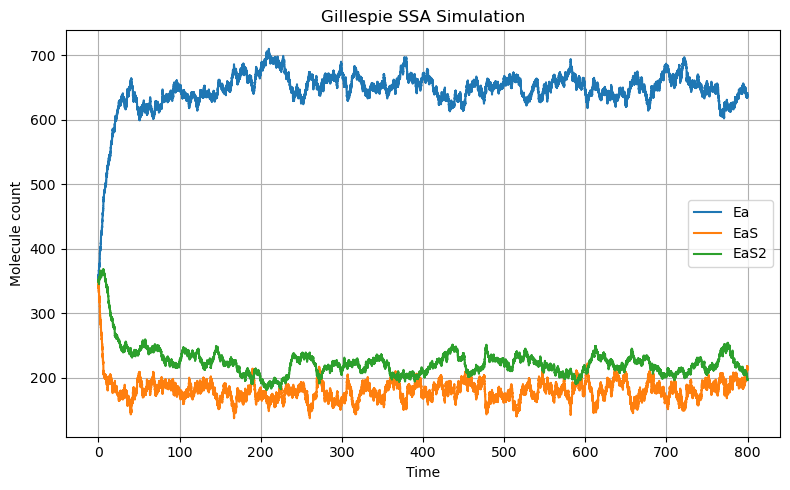

In [24]:
# 1) Change store_trajectories = False (default = True) to skip trajectory plotting. This offers up to 100x speed up.
#
# 2) Add an explicit set of starting populations as a list (in same order as 'species_names' used in ModuleProperties),
#    default is to use pre-defined list 'initial_counts' in RunSSA.

SIM1.run_SSA_and_plot_counts(store_trajectories=True, starting_pops=None)

In [8]:
SIM1.count_values[0]

350

In [ ]:
SIM2.run_SSA_and_plot_counts(True)

# Plot the distribution of currents and forces over a set number of iterations 

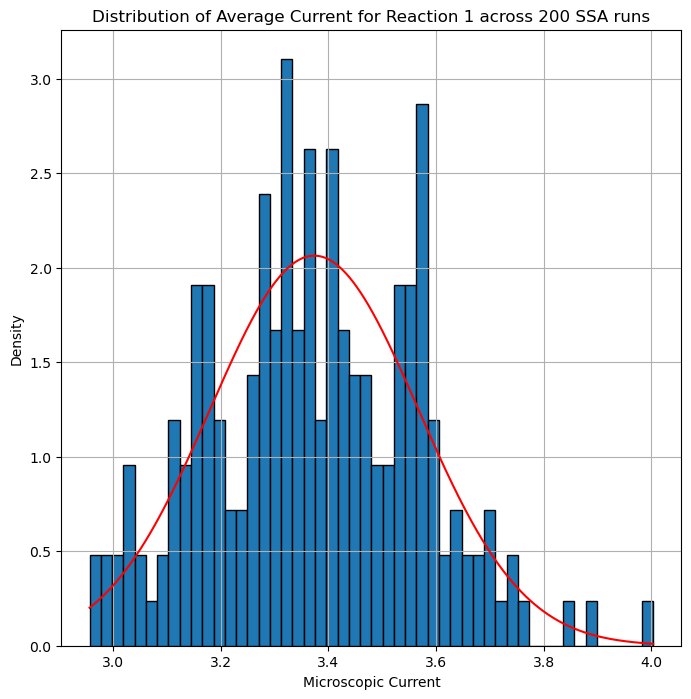

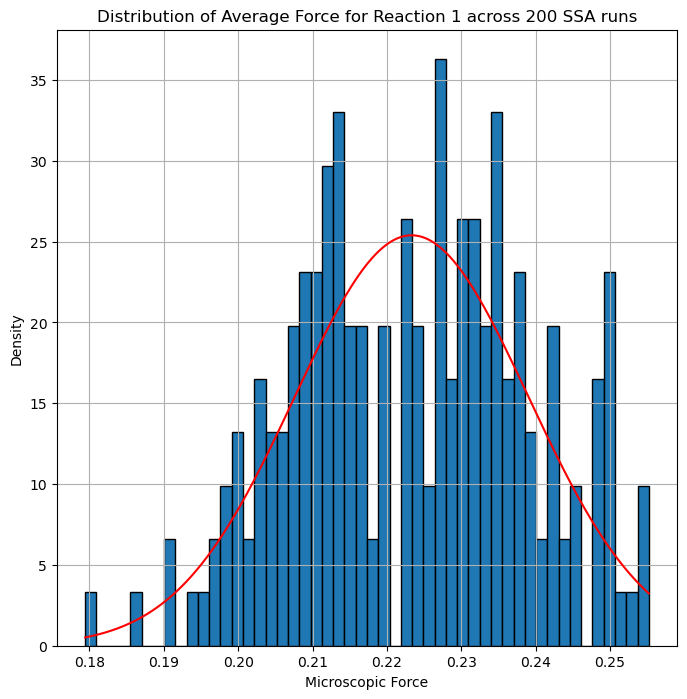

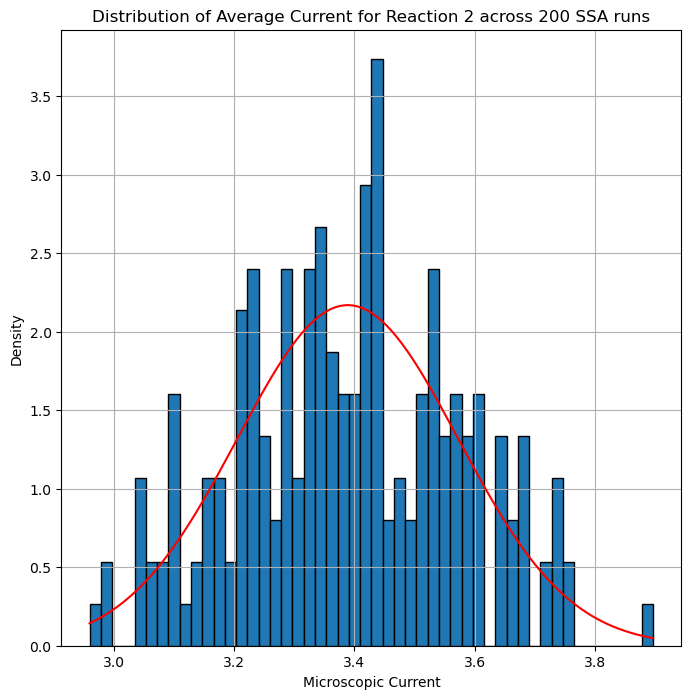

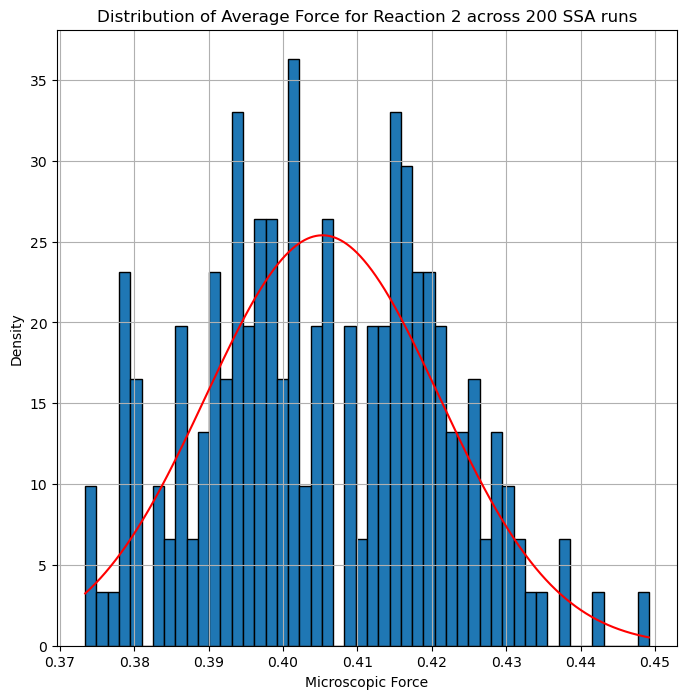

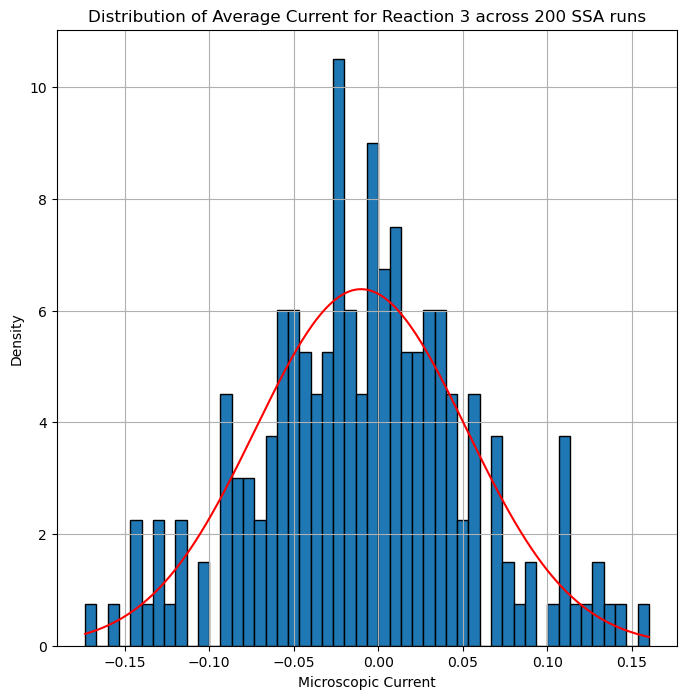

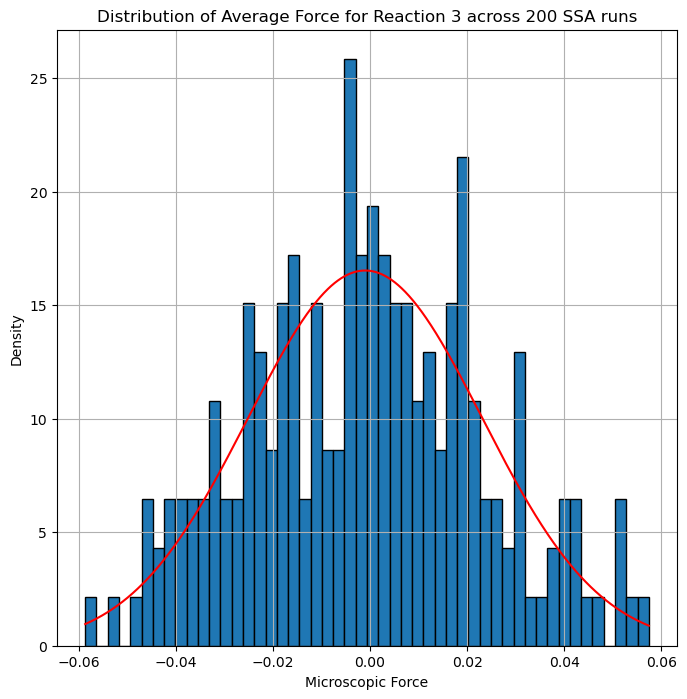

In [ ]:
# This attribute allows us to see how well the currents and forces converge to a Gaussian for a different number of SSA repeats. The plotted data is time averaged current and force across all
# the reactions in the CRN after each individual run of SSA (out of num_iterations). This is helpful for determining how many iterations we should run
# when we want to average these values. The default values are bins=50, num_iterations = 50, Gaussian_points = 1000. Reactions are in order of the columns of the inputted stoichiometric matrix.

SIM1.plot_gaussian_comparison(bins=50, num_iterations=250, Gaussian_points=1000)


In [ ]:
SIM2.plot_gaussian_comparison(bins=50, num_iterations=2000, Gaussian_points=1000)

# Create I-F curves for the reactions in the module for a varied initial species count

## Compute I-F data from simulation

In [ ]:
# Run SSA sweeps over a varying initial count. In this line, we vary the species at position 3 in species_names ('S') with integer 
# values between 50 and 500, running 40 iterations for each value of 'S'. We opt for 'verbose=True' so that we might track the progress
# through the various 'S' values. The 'covariance_reaction_indicies' tells the code which currents to sample the covariance between,
# this should be the set of currents in the fundamental current vector. For module 1, I = j1, so we set this = [0]. For module 2,
# I_ = (j3, j5) so we choose = [2, 4].

# If desire, one can change multiple species by using a list of indices e.g. [1,3] changes species at index 0 and 2, and passing a list
# of lists of values to vary through (these must be the same length).

# Module 1

SIM1.run_IF_sweep(
    
        species_index=[2,3,4],
        count_values=[np.linspace(50,500,50,dtype='int'),np.linspace(10,100,50,dtype='int'),np.linspace(20,200,50,dtype='int')],
        total_iterations=10, 
        covariance_reaction_indices=[0],   
        verbose=True)

# SIM1.run_IF_sweep(
    
#         species_index=[3],
#         count_values=[np.linspace(50,500,50,dtype='int')],
#         total_iterations=10, 
#         covariance_reaction_indices=[0],   
#         verbose=True)



Sweep 1/5  ([EaS2] = 50, [S] = 10, [Na] = 20)
Sweep 2/5  ([EaS2] = 162, [S] = 32, [Na] = 65)
Sweep 3/5  ([EaS2] = 275, [S] = 55, [Na] = 110)
Sweep 4/5  ([EaS2] = 387, [S] = 77, [Na] = 155)
Sweep 5/5  ([EaS2] = 500, [S] = 100, [Na] = 200)
Total sweep time: 2.56 s


(array([[-0.40333039, -0.37333061, -0.03999971],
        [-0.4366342 , -0.46996505,  0.01999851],
        [-0.74997828, -0.76331123,  0.04999855],
        [-0.45999341, -0.55999198,  0.01666643],
        [-0.83332711, -0.92332644,  0.09333264],
        [-0.59666505, -0.66999819,  0.13333297],
        [-0.49999342, -0.57332578,  0.01333316],
        [-0.74663567, -0.71997011,  0.01333278],
        [-0.20333176, -0.129999  ,  0.00333331],
        [-1.06330177, -0.95663827, -0.08666409]]),
 array([[-0.01820248, -0.04633604, -0.00314688],
        [-0.02422566, -0.04031286, -0.00725318],
        [-0.02219481, -0.04234371, -0.01239013],
        [-0.0263356 , -0.03820292, -0.01041078],
        [-0.03732484, -0.02721368, -0.0044145 ],
        [-0.00634334, -0.05819518,  0.02304465],
        [-0.00376196, -0.06077656,  0.00884877],
        [-0.02418197, -0.04035655,  0.01629249],
        [-0.00407825, -0.06046027,  0.00493632],
        [-0.01082108, -0.05371744, -0.01213545]]))

In [ ]:
# Module 2

SIM2.run_IF_sweep(
    
        species_index=4,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=10, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

In [ ]:
SIM2.species_names

## Plot the curves

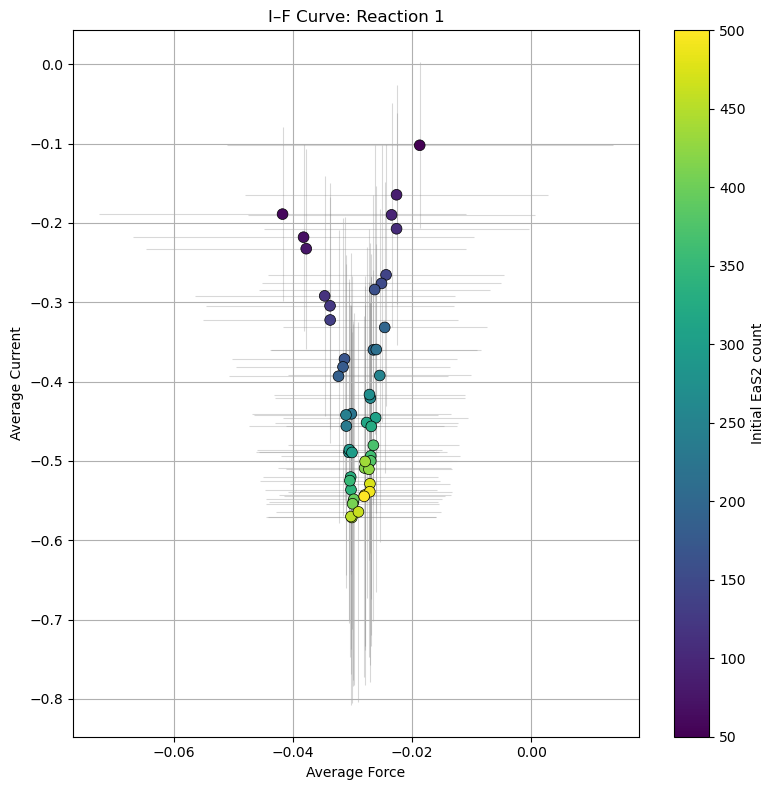

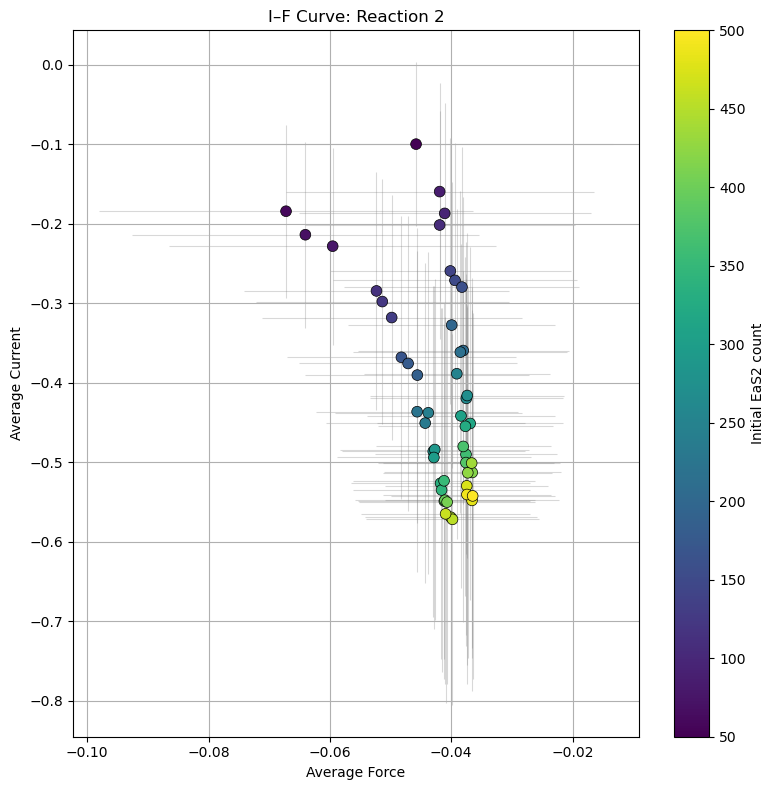

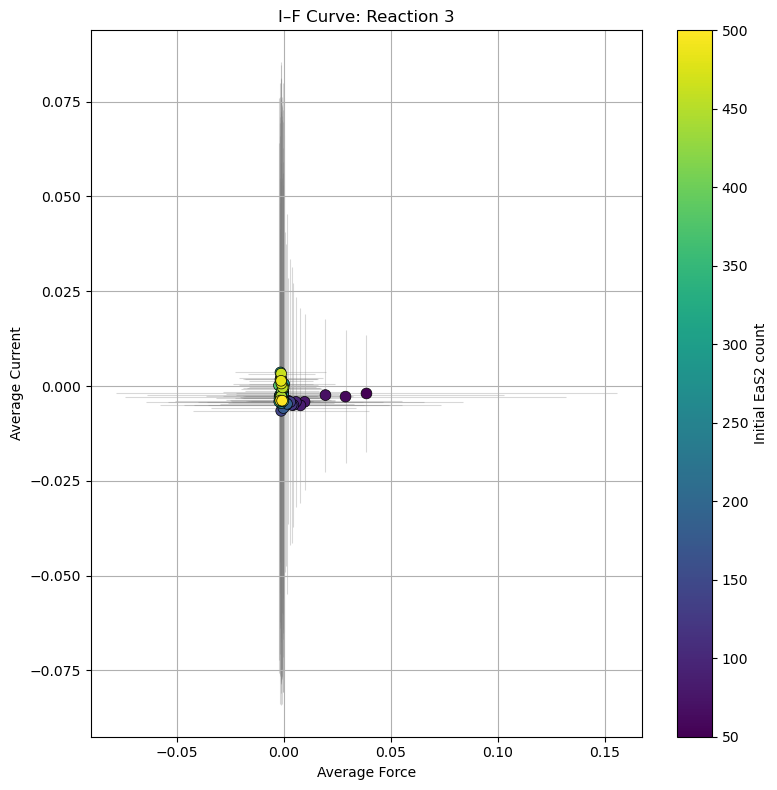

In [7]:
# Now, we can plot the resulting I-F curves. We can select which to plot with 'reaction_indices', note that 'reaction 1' has index 0.
# Default is to plot all reactions. We can opt to plot any analytical results we may have calculated by passing these as lists into
# 'analytical_currents' and 'analytical_forces'.

# Module 1

SIM1.plot_IF_curves(

        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

In [ ]:
# Module 2

SIM2.plot_IF_curves(

        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

# Calculate and plot scalar or eigenvalues of conductance for inividual CRNs

In [8]:
# Calculate conductance of our individual CRNs. Again, we can opt to plot any analytical results for the conductance by passing the 
# currents and forces as lists into 'analytical_currents' and 'analytical_forces'.

SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

([Matrix([[1.55529110721407]]),
  Matrix([[1.70550665518078]]),
  Matrix([[2.10445132411613]]),
  Matrix([[2.36040479449216]]),
  Matrix([[2.49671137724448]]),
  Matrix([[2.91095352562187]]),
  Matrix([[3.15211619220824]]),
  Matrix([[3.30195608774111]]),
  Matrix([[3.52685441230047]]),
  Matrix([[3.82371647743649]]),
  Matrix([[4.0524766798613]]),
  Matrix([[4.23054661906121]]),
  Matrix([[4.3587445336266]]),
  Matrix([[4.63980079139014]]),
  Matrix([[4.80049323103508]]),
  Matrix([[5.02079027258677]]),
  Matrix([[5.09702300453527]]),
  Matrix([[5.57123294424219]]),
  Matrix([[5.58702552236747]]),
  Matrix([[5.77497724204574]]),
  Matrix([[6.00927686269956]]),
  Matrix([[5.86636467415481]]),
  Matrix([[6.04258591133914]]),
  Matrix([[6.50711329466121]]),
  Matrix([[6.44668195912337]]),
  Matrix([[6.62278438700674]]),
  Matrix([[6.61389160009037]]),
  Matrix([[6.74080720490357]]),
  Matrix([[6.8662340121448]]),
  Matrix([[6.99174920393293]]),
  Matrix([[7.05556859215514]]),
  Matrix([[

In [ ]:
SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

No difference plotted: Option Deprecated


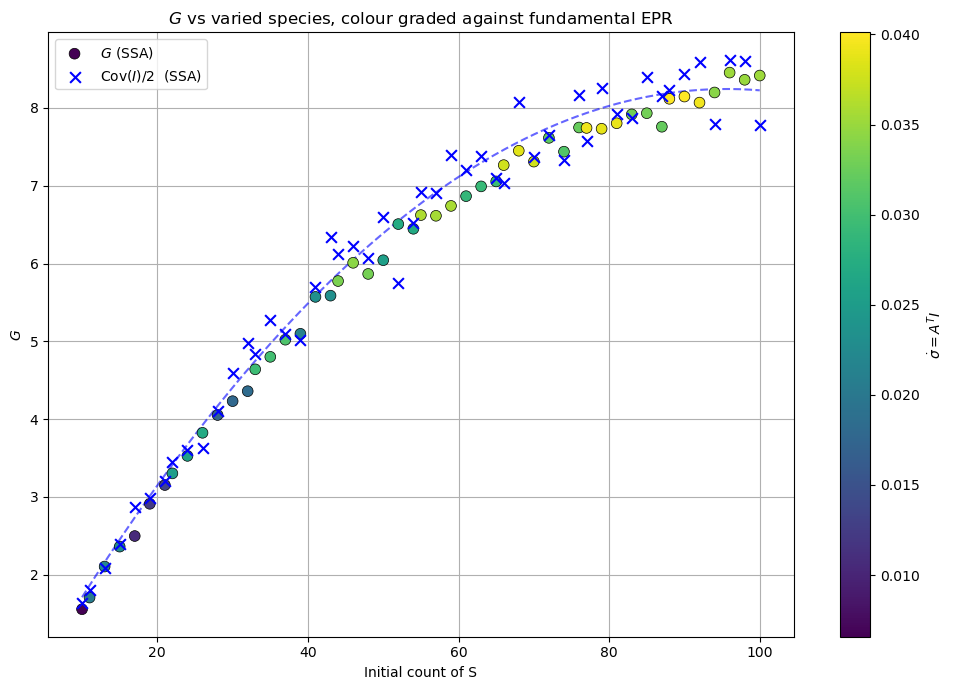

In [10]:
# Plot the conductances. For module 1, we expect a scalar value, so the code will plot this scalar conductance vs the count values.
# We can opt to plot the covariance of the currents and forces with 'show_covariance=True', this plots Cov(I)/2. Also, we can plot
# the difference between the numerical and analytical conductances with 'show_difference=True', this plots the value |G - Cov(I)/2|. 
# We can also fit a polynomial of order 'fit_order' to the numerical conductance values.

# Module 1

SIM1.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )



No difference plotted: Option Deprecated


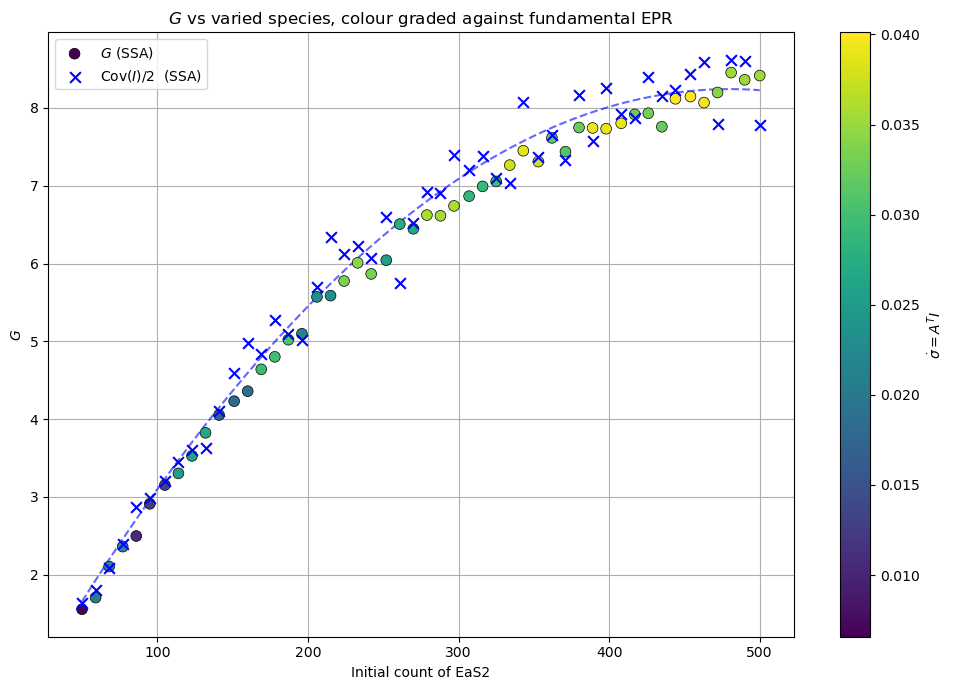

In [13]:
# Plot the conductances. For module 1, we expect a scalar value, so the code will plot this scalar conductance vs the count values.
# We can opt to plot the covariance of the currents and forces with 'show_covariance=True', this plots Cov(I)/2. Also, we can plot
# the difference between the numerical and analytical conductances with 'show_difference=True', this plots the value |G - Cov(I)/2|. 
# We can also fit a polynomial of order 'fit_order' to the numerical conductance values.

# Module 1

SIM1.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )



In [ ]:
# The code automatically detects whether the conductance is scalar or a matrix.

# Module 2

SIM2.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )

# Numerical Conductance of Serially Connected CRNs

In [25]:
# First, create the following module variables for the two CRNs we want to combine.

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)

# We must create the individual resistance matrices for each module before combining them

module1_for_simulating.calculate_fundamental_resistance_matrix() 

module2_for_simulating.calculate_fundamental_resistance_matrix()

# Then prepare the module variables for simulation

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)



In [24]:
module2_for_simulating.species_names

['Eb', 'EbF', 'EbW', 'Eb*', 'Na', 'Nb', 'F', 'W']

In [26]:
# Compute data that will be combined. 

# Module 1

SIM1.run_IF_sweep(
    
        species_index=[3],
        count_values=[np.linspace(50,500,50,dtype='int')],
        total_iterations=50, 
        covariance_reaction_indices=[0],   
        verbose=True)

# Module 2

SIM2.run_IF_sweep(
    
        species_index=[5],
        count_values=[np.linspace(50,500,50,dtype='int')],
        total_iterations=50, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

Sweep 1/50  ([S] = 50)
Sweep 2/50  ([S] = 59)
Sweep 3/50  ([S] = 68)
Sweep 4/50  ([S] = 77)
Sweep 5/50  ([S] = 86)
Sweep 6/50  ([S] = 95)
Sweep 7/50  ([S] = 105)
Sweep 8/50  ([S] = 114)
Sweep 9/50  ([S] = 123)
Sweep 10/50  ([S] = 132)
Sweep 11/50  ([S] = 141)
Sweep 12/50  ([S] = 151)
Sweep 13/50  ([S] = 160)
Sweep 14/50  ([S] = 169)
Sweep 15/50  ([S] = 178)
Sweep 16/50  ([S] = 187)
Sweep 17/50  ([S] = 196)
Sweep 18/50  ([S] = 206)
Sweep 19/50  ([S] = 215)
Sweep 20/50  ([S] = 224)
Sweep 21/50  ([S] = 233)
Sweep 22/50  ([S] = 242)
Sweep 23/50  ([S] = 252)
Sweep 24/50  ([S] = 261)
Sweep 25/50  ([S] = 270)
Sweep 26/50  ([S] = 279)
Sweep 27/50  ([S] = 288)
Sweep 28/50  ([S] = 297)
Sweep 29/50  ([S] = 307)
Sweep 30/50  ([S] = 316)
Sweep 31/50  ([S] = 325)
Sweep 32/50  ([S] = 334)
Sweep 33/50  ([S] = 343)
Sweep 34/50  ([S] = 353)
Sweep 35/50  ([S] = 362)
Sweep 36/50  ([S] = 371)
Sweep 37/50  ([S] = 380)
Sweep 38/50  ([S] = 389)
Sweep 39/50  ([S] = 398)
Sweep 40/50  ([S] = 408)
Sweep 41/50  ([

(array([[ -2.89999693,  21.27497748,  -2.8966636 , -24.14664111,
         -24.17997441],
        [ -3.31999071,  20.7382753 ,  -3.32665736, -24.12659915,
         -24.058266  ],
        [ -3.0766663 ,  20.88333087,  -3.10833297, -23.91999718,
         -23.9933305 ],
        [ -2.69833234,  21.17165886,  -2.63833236, -23.8549912 ,
         -23.80832455],
        [ -3.07830878,  21.43149569,  -3.10664188, -24.52313769,
         -24.55813741],
        [ -2.96664459,  21.31984131,  -2.97664451, -24.30648575,
         -24.32481894],
        [ -3.28666396,  20.98331608,  -3.24833066, -24.26664672,
         -24.16498013],
        [ -2.99665825,  21.50827289,  -2.96332501, -24.5065978 ,
         -24.42993135],
        [ -3.28332237,  21.32326216,  -3.29665566, -24.62825113,
         -24.64991772],
        [ -3.09165172,  20.95656538,  -3.07331848, -24.00821729,
         -23.99321736],
        [ -3.24829266,  21.18140147,  -3.25662589, -24.39136128,
         -24.39302793],
        [ -3.00160997

In [27]:
# Compute lists of the numerical conductance for each module, we will not overlay any analytical results.

module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

In [28]:
# Now we use the CombiningModules class to combine the data from the two modules, this essentially involves replacing the symbolic
# values of resistance with the numerical results calculated above, and the same code as the symbolic case follows.

module3 = CombiningModules(module1_for_simulating, module2_for_simulating, module1_conductances, module2_conductances)

# Store the numerical combined condictance matrices

combined_Gs = module3.numerical_combined_fundamental_CMs# Acquire the serially combined conductance matrices

In [29]:
analytical_G_np = np.array(combined_Gs, dtype=float)
eigenvalues = np.array([np.linalg.eigvals(analytical_G_np[i]) 
                            for i in range(analytical_G_np.shape[0])])

eigenvalues


array([[ 2.8248228 , 10.06908283],
       [ 2.83297584, 10.02882093],
       [ 3.01700209, 10.06605623],
       [ 2.9647376 , 10.01334741],
       [ 2.97642088,  9.94361178],
       [ 2.95562412,  9.85344109],
       [ 2.95122062,  9.7818008 ],
       [ 2.91674125,  9.76676337],
       [ 2.88246981,  9.66968253],
       [ 2.85319752,  9.63350663],
       [ 2.81928945,  9.53353457],
       [ 2.7607882 ,  9.53246579],
       [ 2.7110694 ,  9.3992207 ],
       [ 2.67129645,  9.3075104 ],
       [ 2.61309361,  9.23012089],
       [ 2.5568838 ,  9.16720484],
       [ 2.51775003,  9.12318613],
       [ 2.46475862,  8.94281471],
       [ 2.41175047,  9.02618504],
       [ 2.35604541,  8.88206176],
       [ 2.3229369 ,  8.83383107],
       [ 2.26172213,  8.67483629],
       [ 2.2105256 ,  8.75818164],
       [ 2.17009438,  8.6050701 ],
       [ 2.12489939,  8.64845548],
       [ 2.08535092,  8.64438059],
       [ 2.04309712,  8.67885931],
       [ 2.00669525,  8.39794528],
       [ 1.9565371 ,

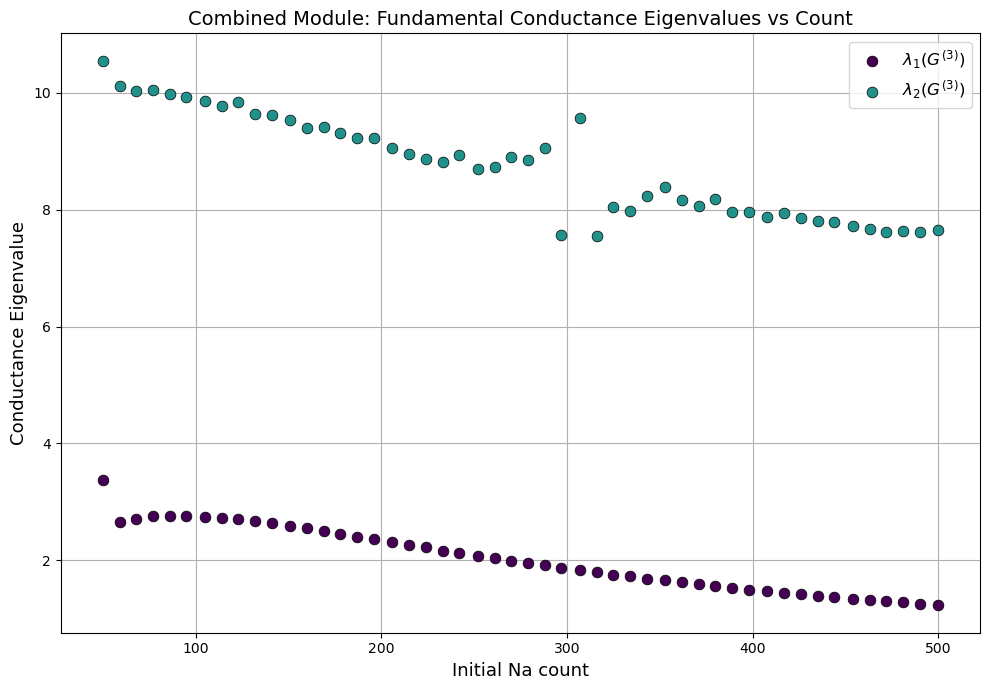

In [31]:
# Use a dedicated function to plot this combined conductance. It is important to include the same count_values as the
# compute_conductances attribute used, and include the species label that is being varied. If the combined_Gs is scalar, this will
# plot a simple line of conductance vs count, if it is a list of matrices, this will plot the eigenvalues of these matrices.

plot_combined_conductance(
    combined_CMs  = combined_Gs,
    count_values  = np.linspace(50, 500, 50, dtype='int'),
    species_label ='Na'
)

### Plotting the conductance directly from the joint SM

In [5]:
# Re-define the module variables for clarity, and calculate their fundamental resistance matrix.

m1 = ModuleProperties(SM, 3, species_names)

m1.calculate_fundamental_resistance_matrix()

m2 = ModuleProperties(SM2, 4, species_names2)

m2.calculate_fundamental_resistance_matrix()

⎡r₂ + r₄ + r₅      -r₂     ⎤
⎢                          ⎥
⎣    -r₂       r₁ + r₂ + r₃⎦

In [6]:
m3 = CombiningModules(m1,m2,left_mod_numerical_CM=None,right_mod_numerical_CM=None) # order matters! Require Left feeds into Right

module3_for_simulating = ModuleProperties(m3.stoich_matrix, m3.num_internal_species, m3.species_names)

In [7]:
# Create combined rates and counts

combined_initial_counts, combined_rates = m3.build_combined_initial_counts_and_rates(
    left_initial_counts  = initial_counts,
    right_initial_counts = initial_counts2,
    left_rates = rates,
    right_rates = rates2
)


=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.
Please enter a single initial count for each:

  Species 'Na':
    Left  module value : 50
    Right module value : 50

=== Combined initial counts ===
  [0] Ea           : 350
  [1] EaS          : 350
  [2] EaS2         : 350
  [3] Na           : 350.0 ← user entered
  [4] Eb           : 350
  [5] EbF          : 350
  [6] EbW          : 350
  [7] Eb*          : 350
  [8] S            : 50
  [9] Nb           : 50
  [10] F            : 50
  [11] W            : 50

=== Combined rates ===
  Reaction  1 (left ) : k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ) : k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ) : k+ = 0.0012,  k- = 0.05
  Reaction  4 (right) : k+ = 0.001,  k- = 0.1
  Reaction  5 (right) : k+ = 0.1,  k- = 0.05
  Reaction  6 (right) : k+ = 0.15,  k- = 0.001
  Reaction  7 (right) : k+ = 0.001,  k- = 0.1
  Reaction  8 (right) : k+ = 0.12,  k- = 0.001


In [8]:
# Create simulation module variable

SIM3 = RunSSA(module3_for_simulating, combined_initial_counts, combined_rates, 800 , 200)

In [20]:
# determine which currents are in the fundamental current vector for this module. We see it is [5,7] (currents j6 and j8)

pprint(module3_for_simulating.fundamental_current_vector)
module3_for_simulating.species_names

⎡-j₈⎤
⎢   ⎥
⎣-j₆⎦


['Ea', 'EaS', 'EaS2', 'Na', 'Eb', 'EbF', 'EbW', 'Eb*', 'S', 'Nb', 'F', 'W']

In [35]:
combined_initial_counts

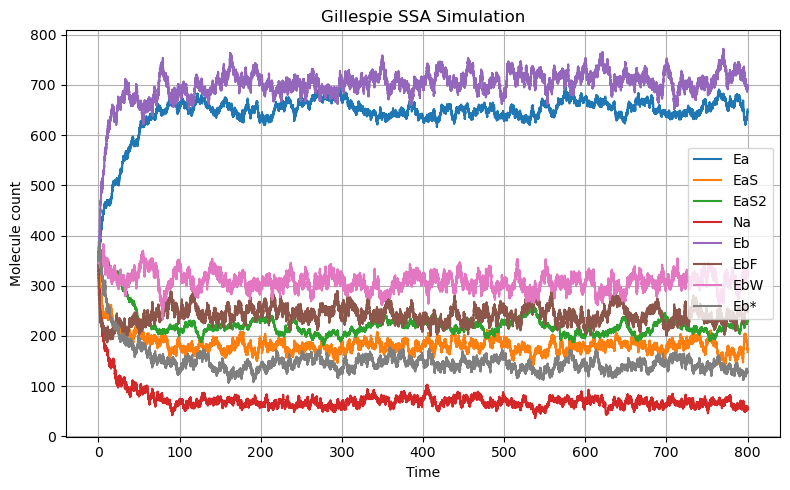

In [36]:
# We can plot the combined module

SIM3.run_SSA_and_plot_counts(store_trajectories=True, starting_pops=[350,350,350,350,350,350,350,350,50,50,50,50])

In [33]:
na_index = SIM3.species_names.index("Na")

burn_mask = SIM3.time_history >= SIM3.burn_in
na_mean = np.mean(SIM3.pop_history[burn_mask, na_index])

print("Steady-state Na:", na_mean)

Steady-state Na: 66.81977526898818


In [21]:
# And again run the sim over many values of a specified species to see the conductance changes (let's try 'S' and 'Nb', as these
# are external species. This is indexes = 8,9 (varying over the same quantity). And lets ignore covariance for now.

# Run the sweep

SIM3.run_IF_sweep(
    
        species_index=[8,9],
        count_values=[np.linspace(50,500,50,dtype='int'),np.linspace(50,500,50,dtype='int')],
        total_iterations=50, 
        covariance_reaction_indices=[5,7],   
        verbose=True)




Sweep 1/50  ([S] = 50, [Nb] = 50)
Sweep 2/50  ([S] = 59, [Nb] = 59)
Sweep 3/50  ([S] = 68, [Nb] = 68)
Sweep 4/50  ([S] = 77, [Nb] = 77)
Sweep 5/50  ([S] = 86, [Nb] = 86)
Sweep 6/50  ([S] = 95, [Nb] = 95)
Sweep 7/50  ([S] = 105, [Nb] = 105)
Sweep 8/50  ([S] = 114, [Nb] = 114)
Sweep 9/50  ([S] = 123, [Nb] = 123)
Sweep 10/50  ([S] = 132, [Nb] = 132)
Sweep 11/50  ([S] = 141, [Nb] = 141)
Sweep 12/50  ([S] = 151, [Nb] = 151)
Sweep 13/50  ([S] = 160, [Nb] = 160)
Sweep 14/50  ([S] = 169, [Nb] = 169)
Sweep 15/50  ([S] = 178, [Nb] = 178)
Sweep 16/50  ([S] = 187, [Nb] = 187)
Sweep 17/50  ([S] = 196, [Nb] = 196)
Sweep 18/50  ([S] = 206, [Nb] = 206)
Sweep 19/50  ([S] = 215, [Nb] = 215)
Sweep 20/50  ([S] = 224, [Nb] = 224)
Sweep 21/50  ([S] = 233, [Nb] = 233)
Sweep 22/50  ([S] = 242, [Nb] = 242)
Sweep 23/50  ([S] = 252, [Nb] = 252)
Sweep 24/50  ([S] = 261, [Nb] = 261)
Sweep 25/50  ([S] = 270, [Nb] = 270)
Sweep 26/50  ([S] = 279, [Nb] = 279)
Sweep 27/50  ([S] = 288, [Nb] = 288)
Sweep 28/50  ([S] = 29

(array([[ 1.25999733e+00,  1.25333068e+00,  2.16666208e-02,
          6.18165359e+00,  4.87498969e+00,  6.18665358e+00,
          1.27999729e+00,  1.26999731e+00],
        [ 1.23666585e+00,  1.23333252e+00,  6.66666227e-03,
          6.01499603e+00,  4.68333024e+00,  6.04832934e+00,
          1.30499914e+00,  1.35166577e+00],
        [ 1.23332958e+00,  1.23666290e+00, -1.66666160e-03,
          5.94664857e+00,  4.81331869e+00,  5.94998190e+00,
          1.15666315e+00,  1.22332961e+00],
        [ 1.39166408e+00,  1.37166412e+00,  1.66666357e-03,
          6.00832218e+00,  4.77165781e+00,  6.06165541e+00,
          1.26999764e+00,  1.24833102e+00],
        [ 1.22166417e+00,  1.21999750e+00,  1.66666326e-02,
          6.24165390e+00,  4.90832329e+00,  6.19165400e+00,
          1.25166411e+00,  1.25166411e+00],
        [ 1.52166041e+00,  1.52666039e+00,  3.83331757e-02,
          6.25664094e+00,  4.75164713e+00,  6.24164100e+00,
          1.49999383e+00,  1.46166066e+00],
        [ 1.2916

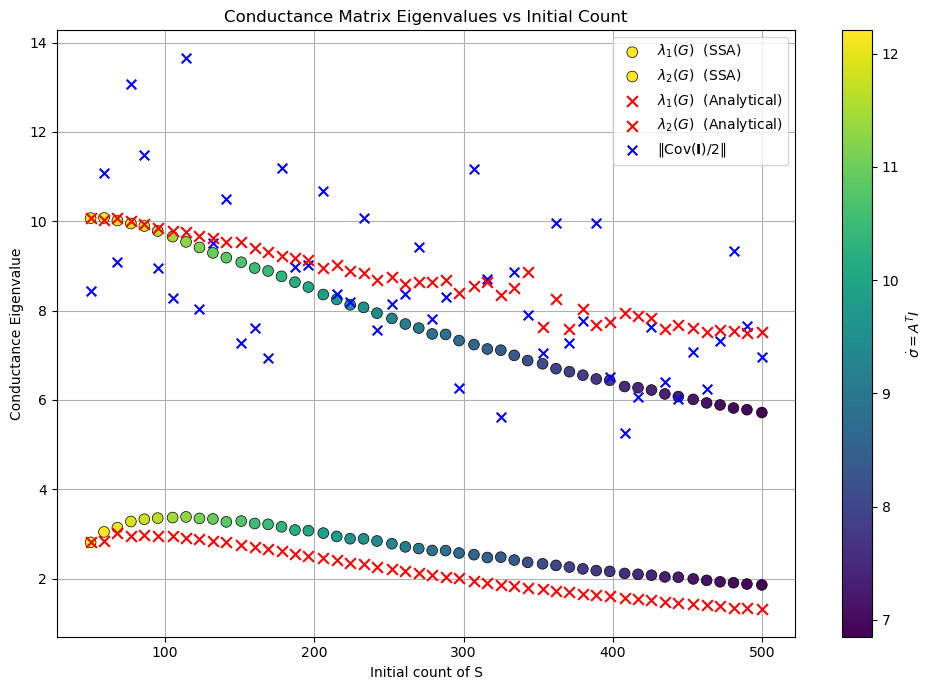

In [30]:
# Compute the conductance and plot.

SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

SIM3.plot_conductance(
        analytical_G=eigenvalues,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=False
    )

In [40]:
via_joint_SM_G = SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

via_joint_SM_G_list = via_joint_SM_G[0]  # extract the list of matrices

safe_matrices = []
safe_indices = []

for i, matrix in enumerate(via_joint_SM_G_list):
    # Remove Nones
    if matrix is None:
        continue
    try:
        # Convert to numpy
        matrix_np = np.array(matrix.tolist(), dtype=np.float64)
        # Remove matrices containing inf or NaN
        if not np.all(np.isfinite(matrix_np)):
            continue
        safe_matrices.append(matrix_np)
        safe_indices.append(i)
    except Exception as e:
        print(f"Skipping matrix {i}: {e}")
        continue

print(f"Kept {len(safe_matrices)} / {len(via_joint_SM_G_list)} matrices")

# Stack into array and compute eigenvalues
safe_matrices_np = np.array(safe_matrices)  # shape: (n_valid, N, N)

eigenvalues_joint_SM = np.array([
    np.linalg.eigvals(safe_matrices_np[i])
    for i in range(safe_matrices_np.shape[0])
])  # shape: (n_valid, N)

eigenvalues_joint_SM = np.sort(eigenvalues_joint_SM.real, axis=1)  # take real part and sort

Kept 50 / 50 matrices


In [42]:
trace_joint_SM_method = []
trace_combined_method = []

for pair in eigenvalues:
    trace_combined_method.append(np.sum(pair))

for pair in eigenvalues_joint_SM:
    trace_joint_SM_method.append(np.sum(pair))

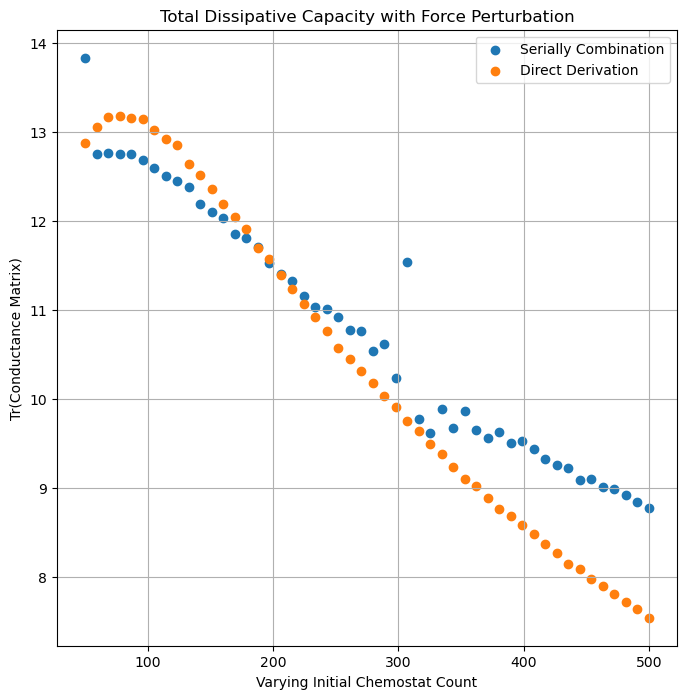

In [50]:
import matplotlib.pyplot as plt
plt.scatter(np.linspace(50,500,50), trace_combined_method, label='Serially Combination')
plt.scatter(np.linspace(50,500,50), trace_joint_SM_method, label='Direct Derivation')
plt.legend()
plt.title('Total Dissipative Capacity with Force Perturbation')
plt.xlabel('Varying Initial Chemostat Count')
plt.ylabel('Tr(Conductance Matrix)')
plt.grid(True)
plt.show()

In [57]:
print(SIM3.species_names)
# print(SIM3.species_index)
print(SIM3.initial_counts)

print(SIM2.species_names)
# print(SIM3.species_index)
print(SIM2.initial_counts)

print(SIM1.species_names)
# print(SIM3.species_index)
print(SIM1.initial_counts)

['Ea', 'EaS', 'EaS2', 'Na', 'Eb', 'EbF', 'EbW', 'Eb*', 'S', 'Nb', 'F', 'W']
[350, 350, 350, 50.0, 350, 350, 350, 350, 50, 50, 50, 50]
['Eb', 'EbF', 'EbW', 'Eb*', 'Na', 'Nb', 'F', 'W']
[350, 350, 350, 350, 50, 50, 50, 50]
['Ea', 'EaS', 'EaS2', 'S', 'Na']
[350, 350, 350, 50, 50]


# Plotting Pre-Calculated Analytical Data

In [4]:
# But let's say we want to overlay some analytical data. For module 1, we can solve the steady state equations and calculate the 
# currents and forces as below, then we can pass these into the attribute to get an overlay.

rates = rates
k1f = rates[0]
k1b = rates[1]
k2f = rates[2]
k2b = rates[3]
k3f = rates[4]
k3b = rates[5]

Na = 50

E_T = 350*3 #initial_counts[0] + initial_counts[1] + initial_counts[2] # total internal species (shouldn't change due to conservation)

analytical_current1 = []
analytical_force1 = []

analytical_current2 = []
analytical_force2 = []

analytical_current3 = []
analytical_force3 = []

S_counts = np.linspace(50,500,50,dtype='int')

for S in S_counts:

    chi = (k2f + k1b)/(k1f*S + k2b*Na)

    j1 = (k1f*k2f*S - k1b*k2b*Na)*E_T / (((k1f*S + k2b*Na)*(1+ k3f*S/k3b))+k2f+k1b)

    f1 = np.log( (k1f*S*(k1b+k2f)) / (k1b*(k1f*S + k2b*Na)) )

    j2 = (E_T *k2f - E_T*k2b*Na*chi)/(1 + chi + k3f*S/k3b )
    
    f2 = np.log( (k2f*(k1f*S + k2b*Na) / (k2b*Na*(k2f + k1b)) ))

    j3 = 0

    f3 = 0

    analytical_current1.append(j1)
    analytical_force1.append(f1)

    analytical_current2.append(j2)
    analytical_force2.append(f2)

    analytical_current3.append(j3)
    analytical_force3.append(f3)

an_currents = [analytical_current1, analytical_current2, analytical_current3]
an_forces = [analytical_force1, analytical_force2, analytical_force3]

In [11]:
SIM1.species_names

['Ea', 'EaS', 'EaS2', 'S', 'Na']

Sweep 1/50  ([S] = 50)
Sweep 2/50  ([S] = 59)
Sweep 3/50  ([S] = 68)
Sweep 4/50  ([S] = 77)
Sweep 5/50  ([S] = 86)
Sweep 6/50  ([S] = 95)
Sweep 7/50  ([S] = 105)
Sweep 8/50  ([S] = 114)
Sweep 9/50  ([S] = 123)
Sweep 10/50  ([S] = 132)
Sweep 11/50  ([S] = 141)
Sweep 12/50  ([S] = 151)
Sweep 13/50  ([S] = 160)
Sweep 14/50  ([S] = 169)
Sweep 15/50  ([S] = 178)
Sweep 16/50  ([S] = 187)
Sweep 17/50  ([S] = 196)
Sweep 18/50  ([S] = 206)
Sweep 19/50  ([S] = 215)
Sweep 20/50  ([S] = 224)
Sweep 21/50  ([S] = 233)
Sweep 22/50  ([S] = 242)
Sweep 23/50  ([S] = 252)
Sweep 24/50  ([S] = 261)
Sweep 25/50  ([S] = 270)
Sweep 26/50  ([S] = 279)
Sweep 27/50  ([S] = 288)
Sweep 28/50  ([S] = 297)
Sweep 29/50  ([S] = 307)
Sweep 30/50  ([S] = 316)
Sweep 31/50  ([S] = 325)
Sweep 32/50  ([S] = 334)
Sweep 33/50  ([S] = 343)
Sweep 34/50  ([S] = 353)
Sweep 35/50  ([S] = 362)
Sweep 36/50  ([S] = 371)
Sweep 37/50  ([S] = 380)
Sweep 38/50  ([S] = 389)
Sweep 39/50  ([S] = 398)
Sweep 40/50  ([S] = 408)
Sweep 41/50  ([

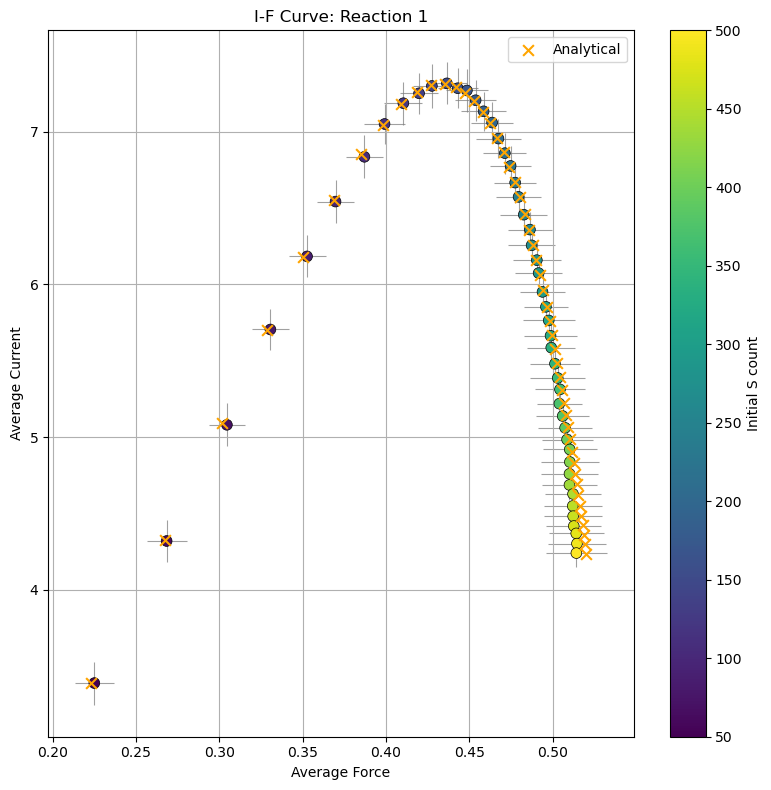

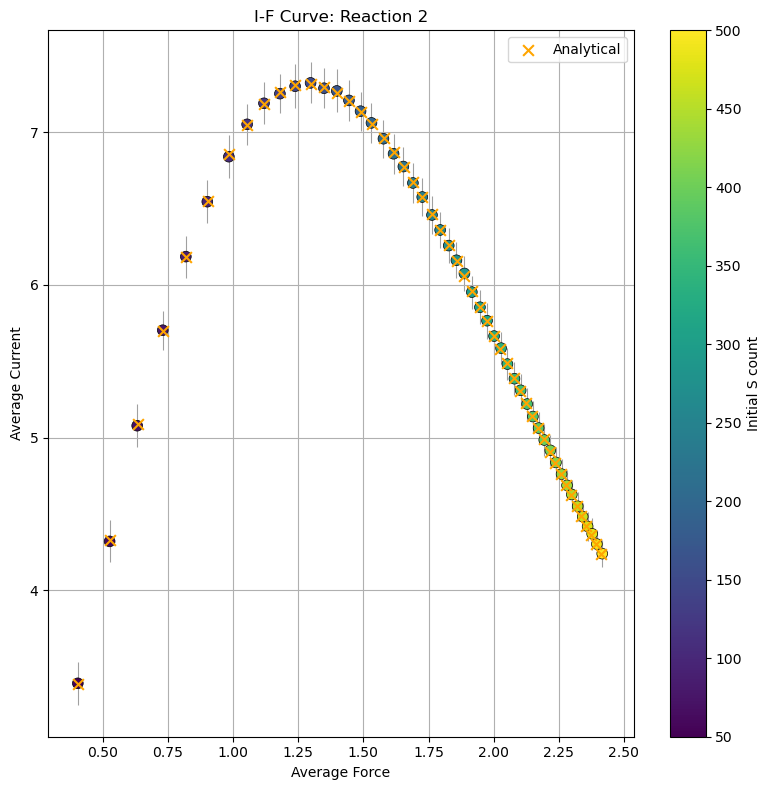

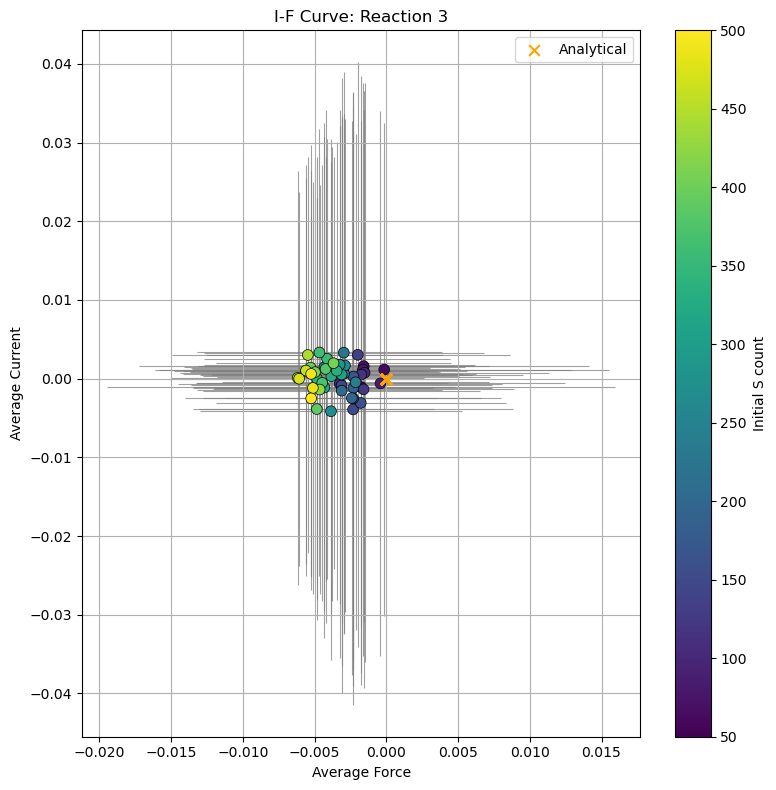

In [5]:
# Now pass these through the calculating attribute and store the result

SIM1.run_IF_sweep(
    
        species_index=[3],
        count_values=[np.linspace(50,500,50,dtype='int')],
        total_iterations=300, 
        covariance_reaction_indices=[0],   
        verbose=True)

_, an_conductances = SIM1.compute_conductances(an_currents, an_forces)

# And plot, with an_conductances passed.

# SIM1.plot_conductance(
#         analytical_G=an_conductances,
#         marker_size=60,
#         cmap='viridis',
#         fit_order=2,
#         show_covariance=True,
#         show_difference=True
#     )

SIM1.plot_IF_curves(
        
        reaction_indices=None,
        analytical_currents=an_currents,
        analytical_forces=an_forces,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )